In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False
desktop = r"C:\Users\Administrator\Desktop"

In [2]:
# 短期数据清洗
file_path = desktop + r"\short-customer-data.csv"
df_short = pd.read_csv(file_path)
print("原始数据行列：", df_short.shape)

print("\n各字段缺失数量：")
print(df_short.isnull().sum())
dup_num = df_short.duplicated(subset="user_id").sum()
print(f"\nuser_id重复记录数：{dup_num}")

# 去缺失+去重
df_short_clean = df_short.dropna().drop_duplicates(subset="user_id")
print(f"清洗完成后数据：{df_short_clean.shape}")

原始数据行列： (41176, 14)

各字段缺失数量：
user_id           0
age               0
job             330
marital          80
education      1730
default        8596
housing         990
loan            990
contact           0
month             0
day_of_week       0
duration          0
poutcome          0
y                 0
dtype: int64

user_id重复记录数：56
清洗完成后数据：(30445, 14)


In [3]:
# 特征二值编码
def bin_transform(x):
    if x in ["no", "否"]:
        return 0
    elif x in ["yes", "是"]:
        return 1
    else:
        return x

encode_cols = ["default", "housing", "loan", "y"]
for col in encode_cols:
    if col in df_short_clean.columns:
        df_short_clean[col] = df_short_clean[col].apply(bin_transform)
        print(f"{col} 编码完毕")

default 编码完毕
housing 编码完毕
loan 编码完毕
y 编码完毕


In [4]:
# 保存result1
save_excel = desktop + r"\result1.xlsx"
df_short_clean.to_excel(save_excel, index=False)
print(f"\n预处理数据已保存至：{save_excel}")


预处理数据已保存至：C:\Users\Administrator\Desktop\result1.xlsx


In [5]:
df = pd.read_excel(save_excel)

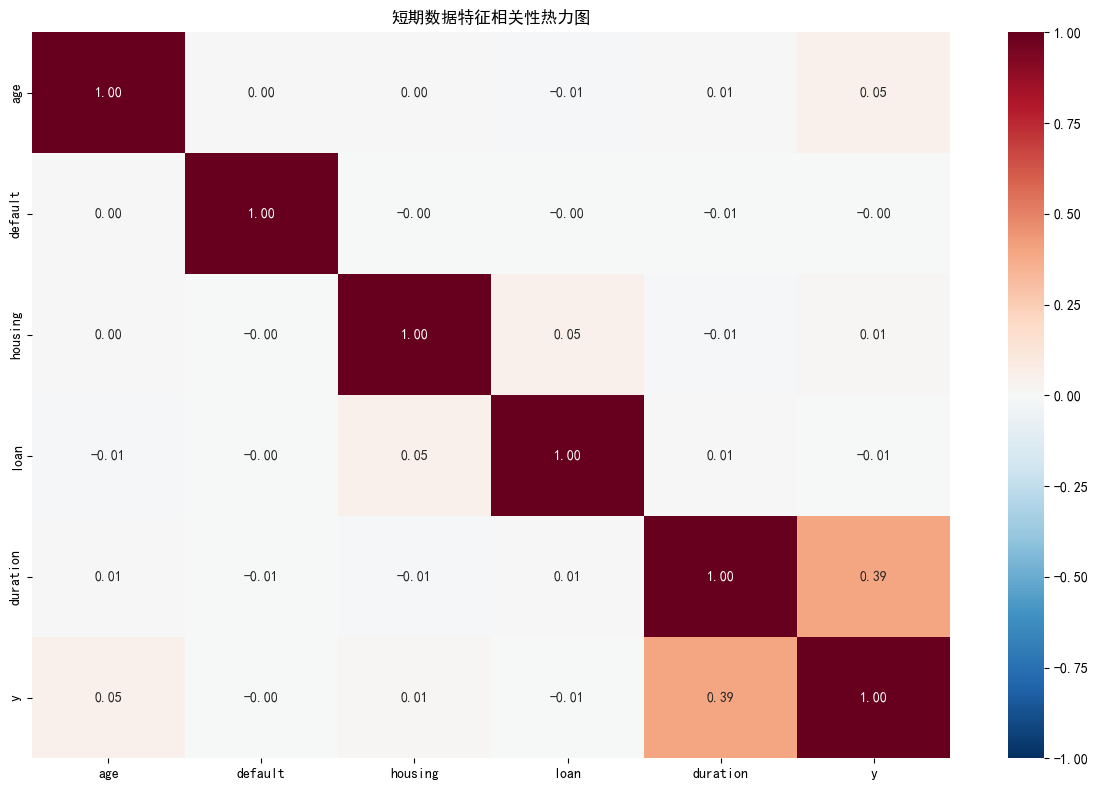

In [6]:
# 1.相关性热力图
plt.figure(figsize=(12,8))
num_data = df.select_dtypes(include=[np.number])
corr = num_data.corr()
sns.heatmap(corr, annot=True, cmap="RdBu_r", fmt=".2f", vmin=-1, vmax=1)
plt.title("短期数据特征相关性热力图")
plt.tight_layout()
plt.savefig(desktop + r"\热力图.png", dpi=300, bbox_inches="tight")
plt.show()

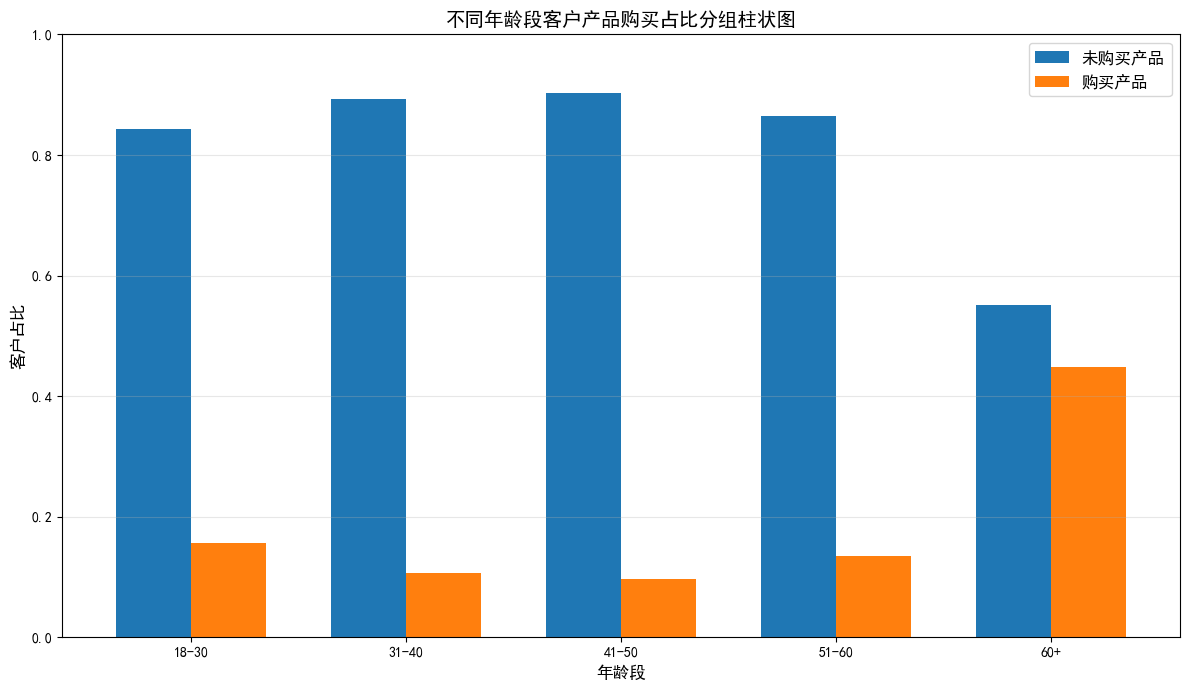

In [7]:
# 2.年龄购买占比柱状图
plt.figure(figsize=(12, 7))

# 1. 对年龄进行分段
bins = [18, 30, 40, 50, 60, 100]  # 分段边界
labels = ['18-30', '31-40', '41-50', '51-60', '60+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)

# 2. 按年龄段和购买结果统计占比
age_group_cross = pd.crosstab(df['age_group'], df['y'], normalize='index')

# 3. 绘制分组柱状图
age_group_cross.plot(kind='bar', ax=plt.gca(), width=0.7)

# 4. 美化图表
plt.title("不同年龄段客户产品购买占比分组柱状图", fontsize=14)
plt.xlabel("年龄段", fontsize=12)
plt.ylabel("客户占比", fontsize=12)
plt.xticks(rotation=0)  # x轴标签不旋转
plt.legend(["未购买产品", "购买产品"], fontsize=12)
plt.ylim(0, 1)  # y轴固定在0-1，符合占比展示
plt.grid(axis='y', alpha=0.3)  # 加一点网格线，更易读

plt.tight_layout()
# 保存高清图片
plt.savefig(r"C:\Users\Administrator\Desktop\年龄分布柱状图.png", dpi=300, bbox_inches="tight")
plt.show()

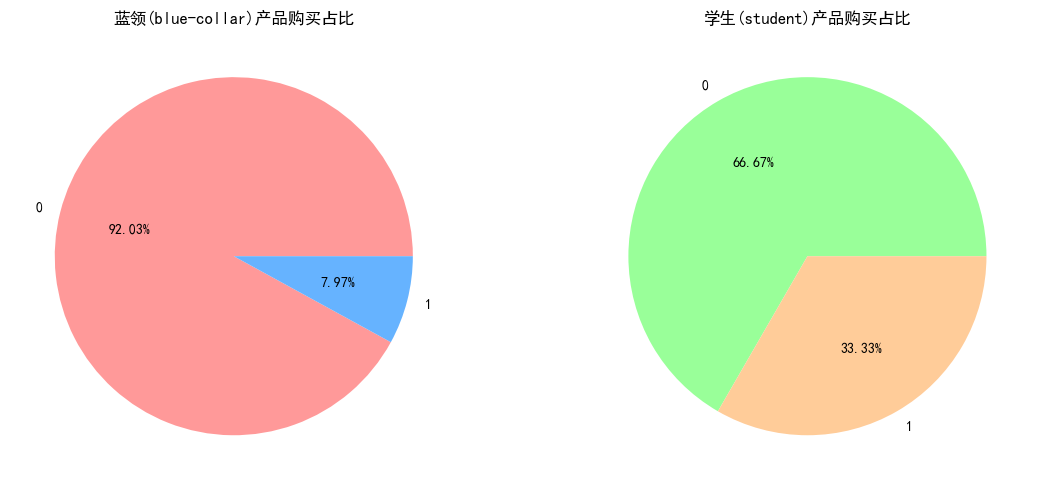

In [8]:
# 3.蓝领&学生双饼图
plt.figure(figsize=(12,5))
# 子图1：蓝领
plt.subplot(1,2,1)
blue_df = df[df["job"]=="blue-collar"]["y"].value_counts()
plt.pie(blue_df,labels=blue_df.index,autopct="%.2f%%",colors=["#ff9999","#66b3ff"])
plt.title("蓝领(blue-collar)产品购买占比")
# 子图2：学生
plt.subplot(1,2,2)
stu_df = df[df["job"]=="student"]["y"].value_counts()
plt.pie(stu_df,labels=stu_df.index,autopct="%.2f%%",colors=["#99ff99","#ffcc99"])
plt.title("学生(student)产品购买占比")
plt.tight_layout()
plt.savefig(desktop + r"\职业购买饼图.png", dpi=300, bbox_inches="tight")
plt.show()

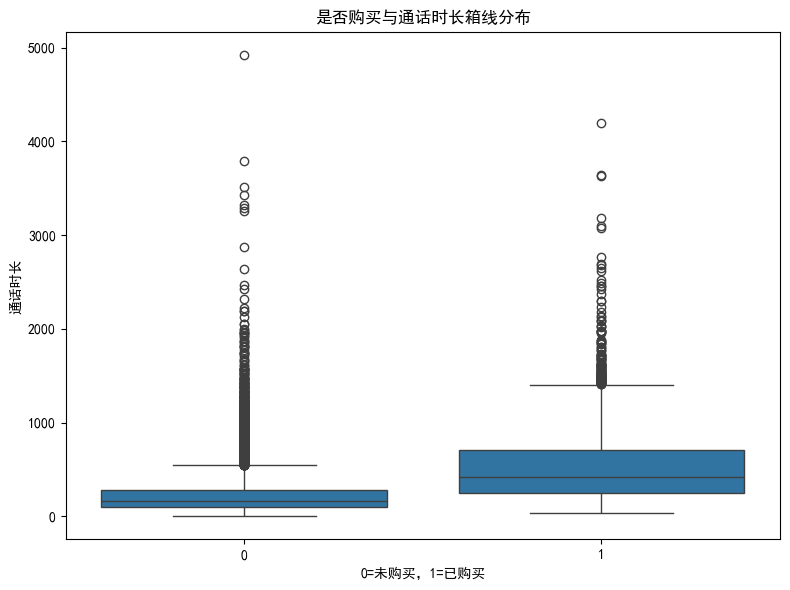

In [9]:
# 4.通话时长箱线图
plt.figure(figsize=(8,6))
sns.boxplot(x="y",y="duration",data=df)
plt.title("是否购买与通话时长箱线分布")
plt.xlabel("0=未购买，1=已购买")
plt.ylabel("通话时长")
plt.tight_layout()
plt.savefig(desktop + r"\通话时长箱线图.png", dpi=300, bbox_inches="tight")
plt.show()